# Feature Exploration with Histograms and Signal Processing
This notebook builds quick visual diagnostics for cervical cytology images.
We will: 
- Load a few images per class
- Show raw histograms
- Apply signal-processing style transforms (contrast stretch, histogram equalization, gamma, edge maps, FFT high-pass)
- Compare before/after side by side

In [7]:
import os
from glob import glob
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [8]:
DATA_ROOT = "/home/al.richard.viana/Documentos/cervical_cancer/data"
CLASSES = ["dyskeratotic", "koilocytotic", "metaplastic", "parabasal", "superficial-intermediate"]
SEED = 7
SAMPLES_PER_CLASS = 2

random.seed(SEED)

def list_images_for_class(class_name):
    pattern = os.path.join(DATA_ROOT, class_name, "im_*", "CROPPED", "*.bmp")
    files = glob(pattern)
    if not files:
        # Some datasets might use jpg or png
        pattern = os.path.join(DATA_ROOT, class_name, "im_*", "CROPPED", "*.*")
        files = [f for f in glob(pattern) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    return sorted(files)

def sample_images_per_class():
    samples = {}
    for cls in CLASSES:
        files = list_images_for_class(cls)
        if not files:
            samples[cls] = []
            continue
        if len(files) <= SAMPLES_PER_CLASS:
            samples[cls] = files
        else:
            samples[cls] = random.sample(files, SAMPLES_PER_CLASS)
    return samples

samples = sample_images_per_class()
{k: len(v) for k, v in samples.items()}

{'dyskeratotic': 2,
 'koilocytotic': 2,
 'metaplastic': 2,
 'parabasal': 2,
 'superficial-intermediate': 2}

In [9]:
# Dataset overview and file counts
if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")

counts = {cls: len(list_images_for_class(cls)) for cls in CLASSES}
count_df = pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
count_df.loc["total"] = count_df["count"].sum()
count_df

,count
dyskeratotic,813
koilocytotic,825
metaplastic,793
parabasal,787
superficial-intermediate,831
total,4049


In [10]:
def load_image(path):
    img = Image.open(path).convert("RGB")
    return np.array(img)

def to_gray(img):
    # Luma transform
    return (0.299 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]).astype(np.float32)

def contrast_stretch(gray):
    p2, p98 = np.percentile(gray, (2, 98))
    if p98 - p2 < 1e-6:
        return gray.copy()
    out = (gray - p2) / (p98 - p2)
    return np.clip(out, 0, 1)

def hist_equalize(gray):
    # Histogram equalization on [0, 1]
    g = np.clip(gray, 0, 1)
    hist, bins = np.histogram(g.flatten(), bins=256, range=(0, 1), density=False)
    cdf = hist.cumsum()
    cdf = cdf / cdf[-1]
    out = np.interp(g.flatten(), bins[:-1], cdf).reshape(g.shape)
    return out

def gamma_correction(gray, gamma=0.8):
    g = np.clip(gray, 0, 1)
    return np.power(g, gamma)

def conv2d(gray, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(gray, ((pad_h, pad_h), (pad_w, pad_w)), mode="reflect")
    out = np.zeros_like(gray, dtype=np.float32)
    for i in range(gray.shape[0]):
        for j in range(gray.shape[1]):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel)
    return out

def sobel_edges(gray):
    kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    gx = conv2d(gray, kx)
    gy = conv2d(gray, ky)
    mag = np.sqrt(gx**2 + gy**2)
    mag = mag / (mag.max() + 1e-6)
    return mag

def local_variance(gray, k=7):
    kernel = np.ones((k, k), dtype=np.float32) / float(k * k)
    mean = conv2d(gray, kernel)
    mean2 = conv2d(gray**2, kernel)
    var = mean2 - mean**2
    var = var - var.min()
    return var / (var.max() + 1e-6)

def fft_highpass(gray, radius=20):
    g = gray - gray.mean()
    f = np.fft.fft2(g)
    fshift = np.fft.fftshift(f)
    rows, cols = gray.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), dtype=np.float32)
    y, x = np.ogrid[:rows, :cols]
    dist = (y - crow)**2 + (x - ccol)**2
    mask[dist <= radius**2] = 0.0
    fshift = fshift * mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    out = np.abs(img_back)
    out = out / (out.max() + 1e-6)
    return out

def entropy_from_gray(gray, bins=256):
    hist, _ = np.histogram(gray.flatten(), bins=bins, range=(0, 1), density=True)
    hist = hist[hist > 0]
    return float(-np.sum(hist * np.log2(hist)))

def skewness(gray):
    m = float(np.mean(gray))
    s = float(np.std(gray))
    if s < 1e-6:
        return 0.0
    return float(np.mean(((gray - m) / s) ** 3))

def extract_features(gray, edges, hp, varmap):
    return {
        "mean": float(np.mean(gray)),
        "std": float(np.std(gray)),
        "skew": skewness(gray),
        "entropy": entropy_from_gray(gray),
        "edge_density": float(np.mean(edges)),
        "high_freq_energy": float(np.mean(hp)),
        "local_var": float(np.mean(varmap)),
    }

def show_image_grid(images, titles, ncols=3, figsize=(10, 8), cmap=None):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)
    for idx, ax in enumerate(axes.ravel()):
        if idx < n:
            ax.imshow(images[idx], cmap=cmap)
            ax.set_title(titles[idx], fontsize=9)
            ax.axis("off")
        else:
            ax.axis("off")
    plt.tight_layout()

def plot_histogram(gray, title):
    plt.hist(gray.flatten(), bins=256, range=(0, 1), color="#34495e")
    plt.title(title, fontsize=9)
    plt.xlabel("Intensity")
    plt.ylabel("Count")

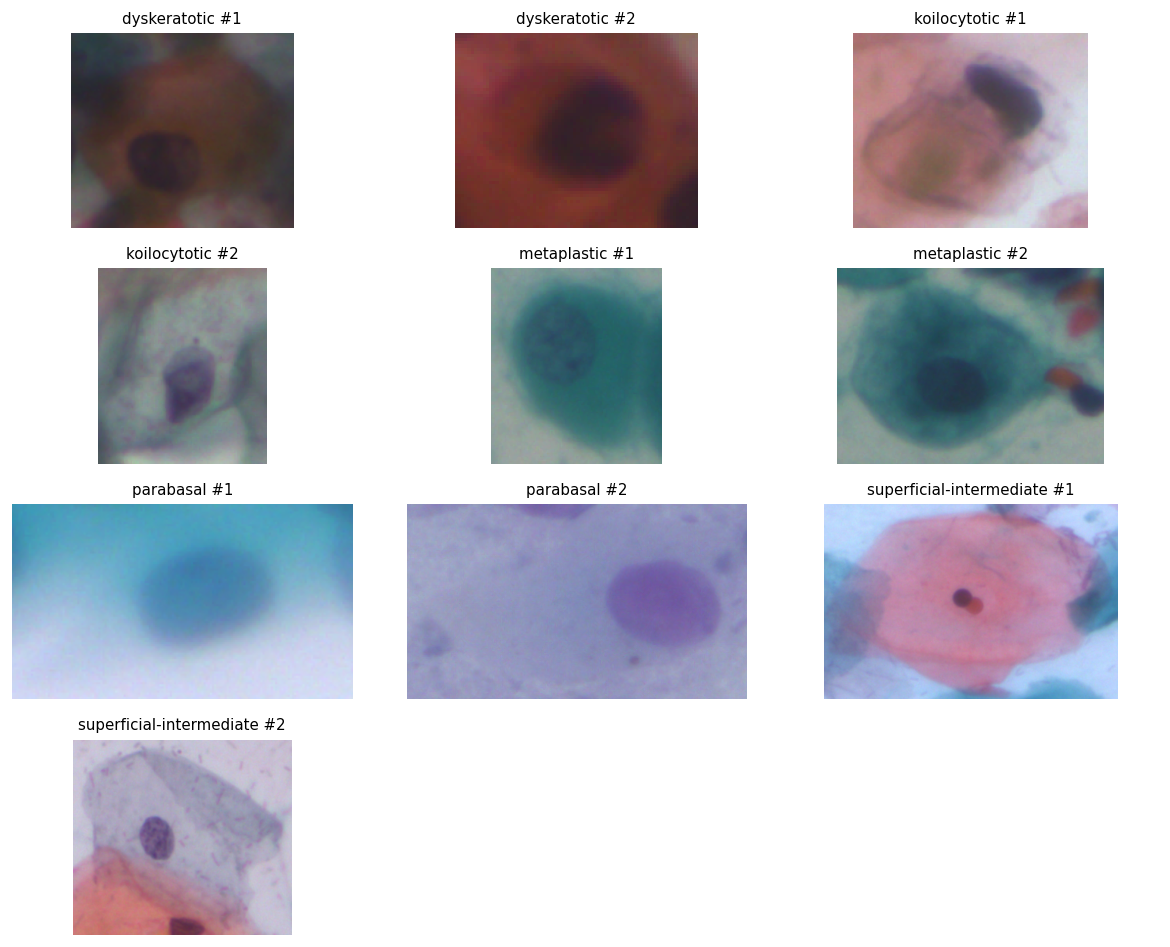

In [11]:
# Show a quick gallery of raw images
raw_images = []
raw_titles = []

for cls, files in samples.items():
    for i, fpath in enumerate(files):
        img = load_image(fpath)
        raw_images.append(img)
        raw_titles.append(f"{cls} #{i+1}")

if raw_images:
    show_image_grid(raw_images, raw_titles, ncols=3, figsize=(10, 8))
else:
    print("No images found. Check DATA_ROOT and folder structure.")

Class: dyskeratotic


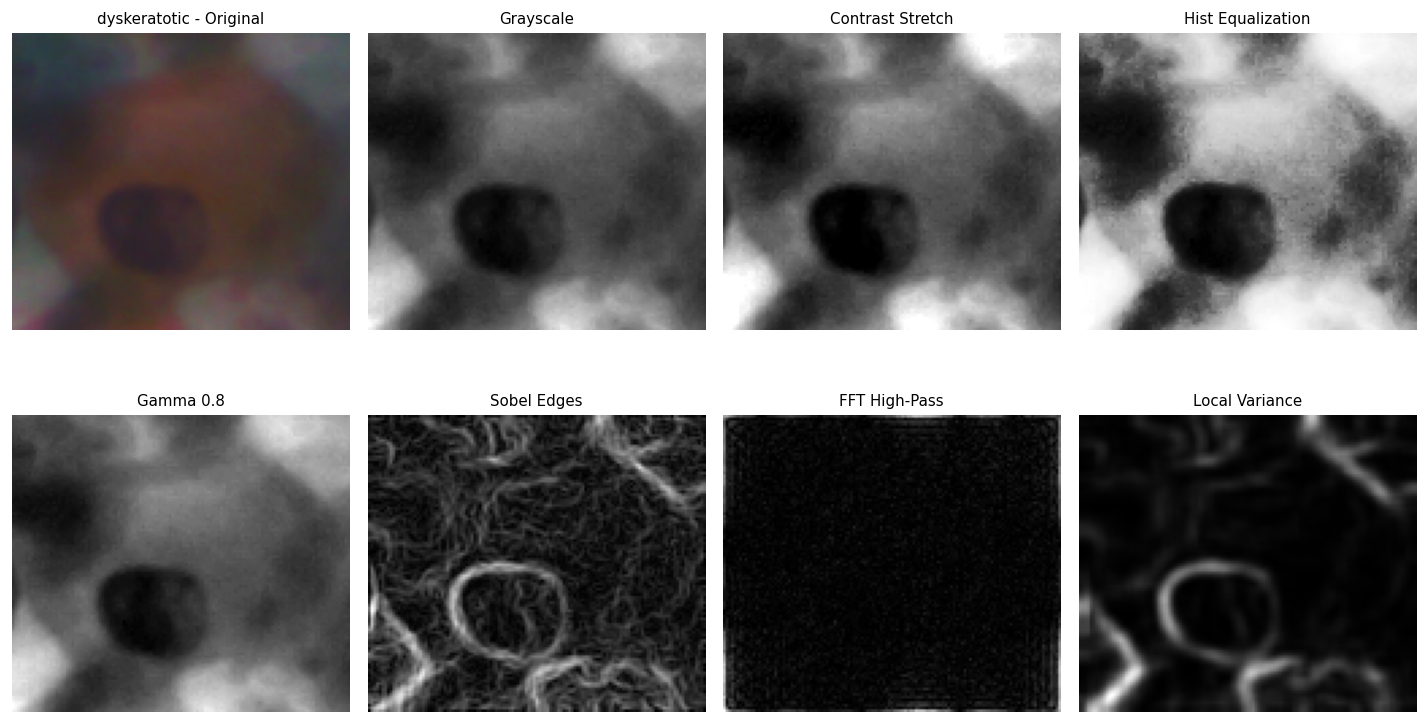

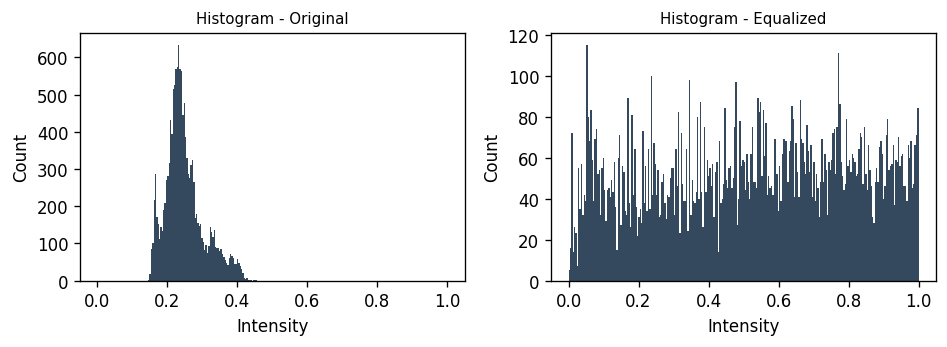

Class: koilocytotic


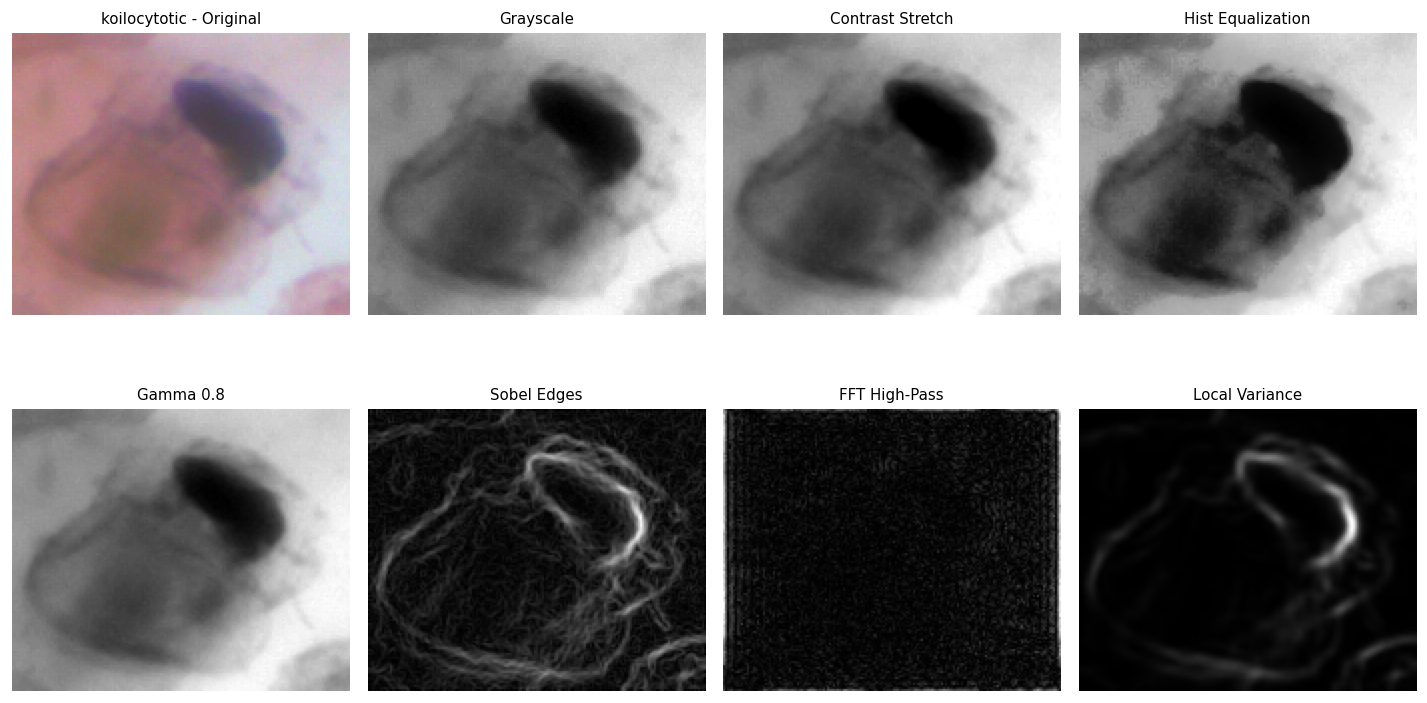

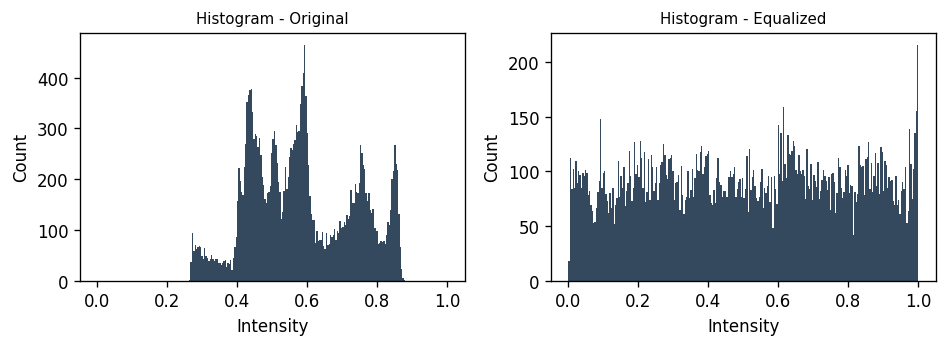

Class: metaplastic


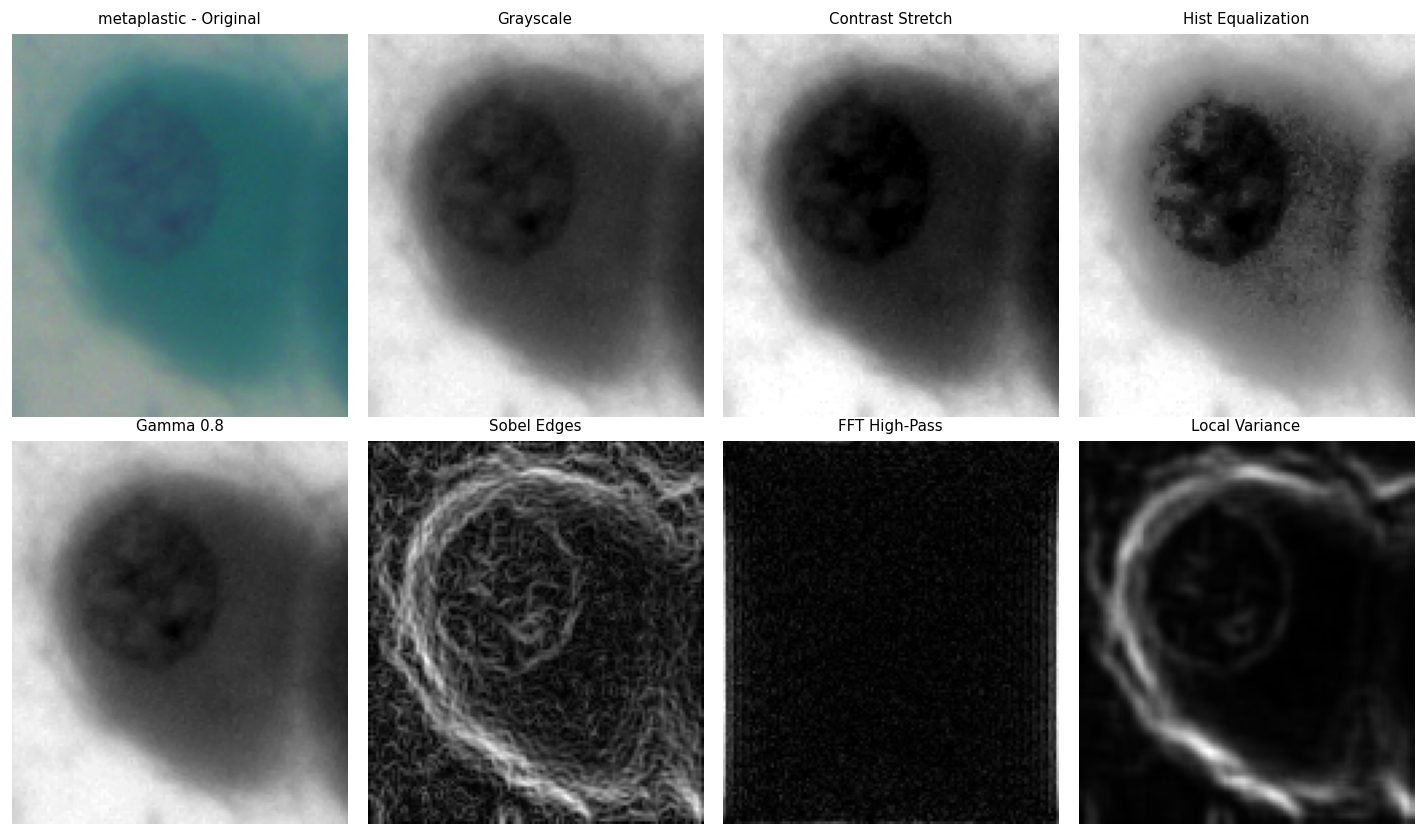

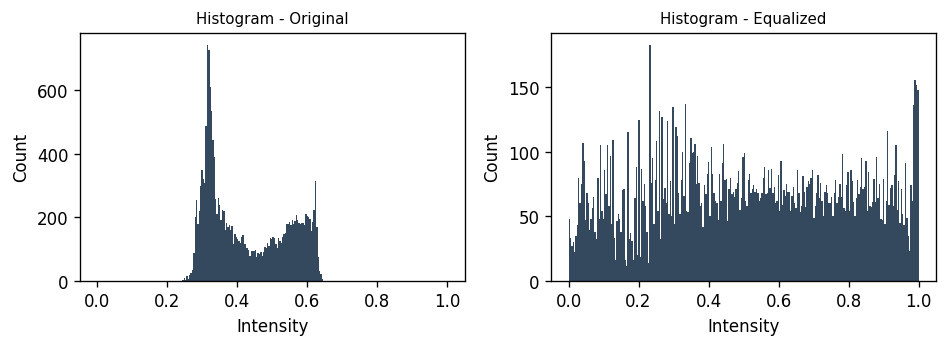

Class: parabasal


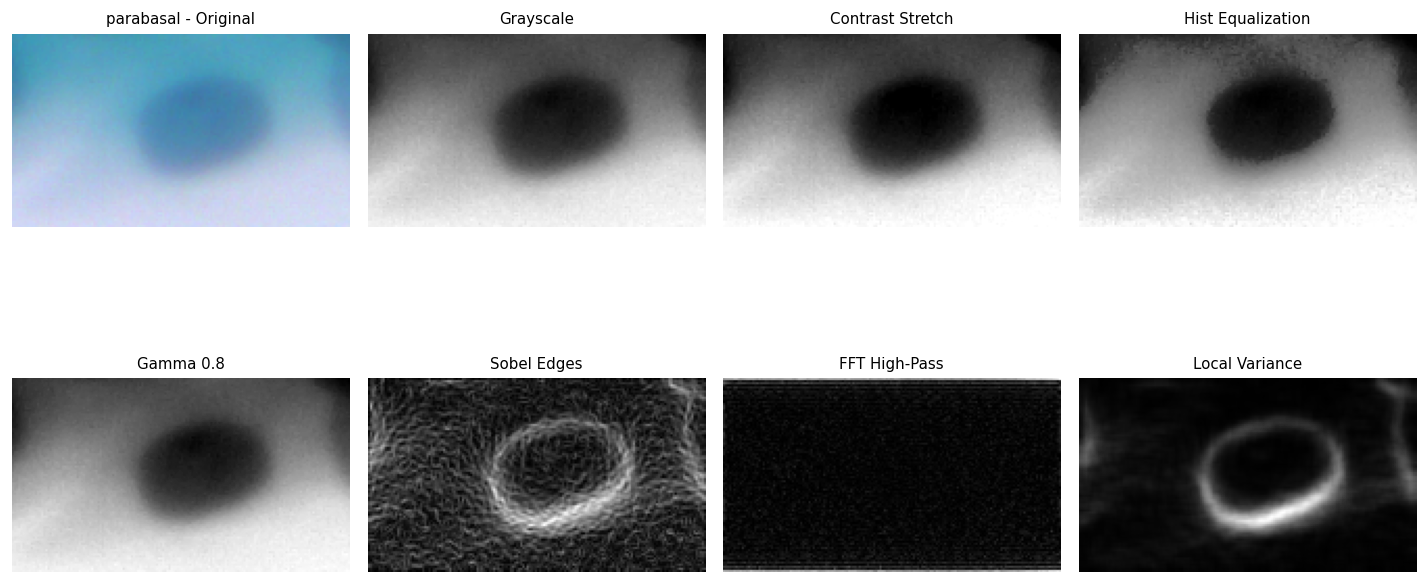

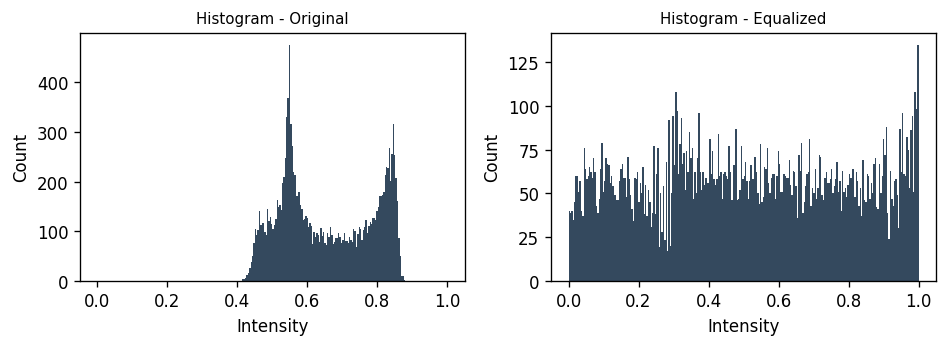

Class: superficial-intermediate


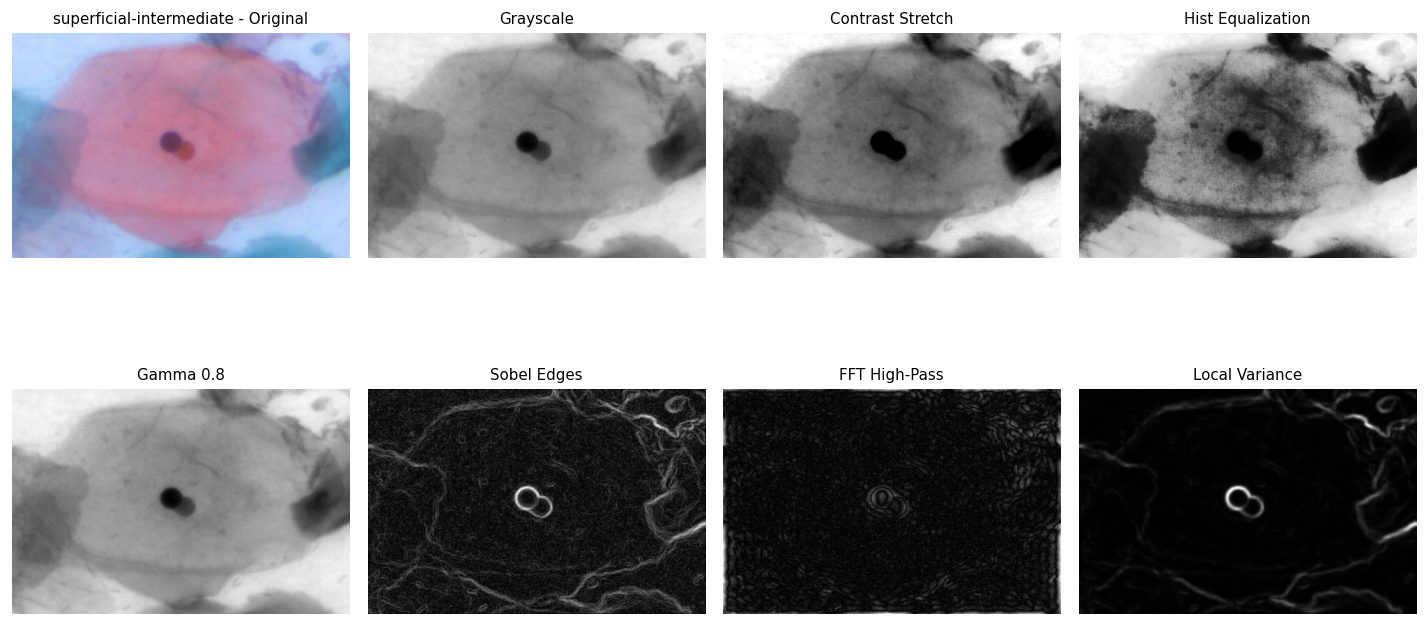

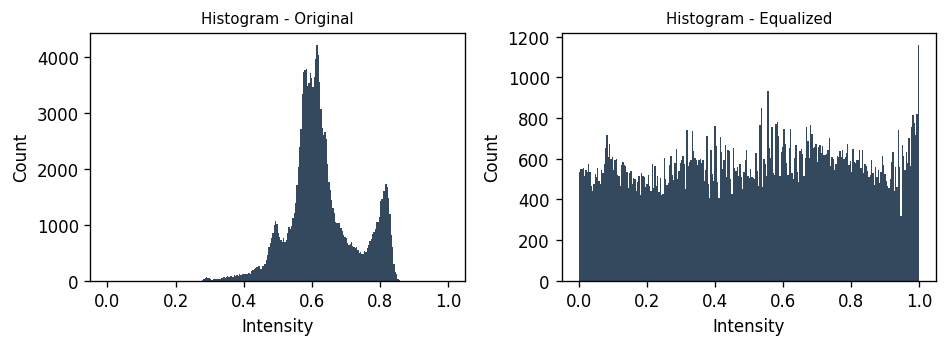

In [12]:
# Before/after preprocessing for one sample per class
for cls, files in samples.items():
    if not files:
        continue
    path = files[0]
    img = load_image(path)
    gray = to_gray(img) / 255.0

    stretched = contrast_stretch(gray)
    equalized = hist_equalize(gray)
    gamma = gamma_correction(gray, gamma=0.8)
    edges = sobel_edges(gray)
    hp = fft_highpass(gray, radius=20)
    varmap = local_variance(gray, k=7)

    images = [img, gray, stretched, equalized, gamma, edges, hp, varmap]
    titles = [
        f"{cls} - Original",
        "Grayscale",
        "Contrast Stretch",
        "Hist Equalization",
        "Gamma 0.8",
        "Sobel Edges",
        "FFT High-Pass",
        "Local Variance"
    ]

    print(f"Class: {cls}")
    show_image_grid(images, titles, ncols=4, figsize=(12, 7), cmap="gray")

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plot_histogram(gray, "Histogram - Original")
    plt.subplot(1, 2, 2)
    plot_histogram(equalized, "Histogram - Equalized")
    plt.tight_layout()
    plt.show()

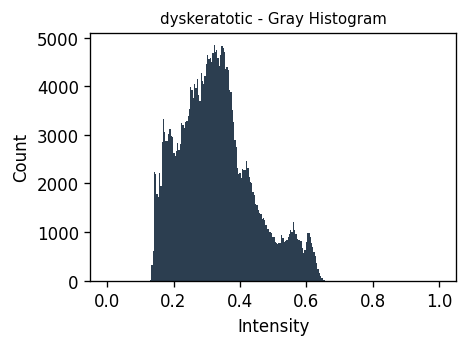

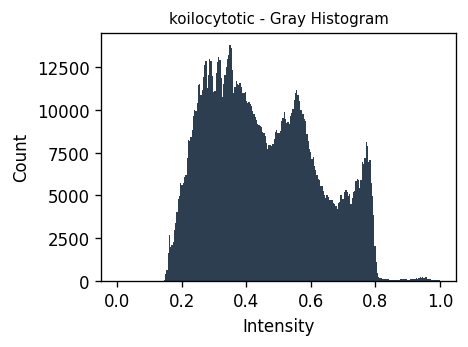

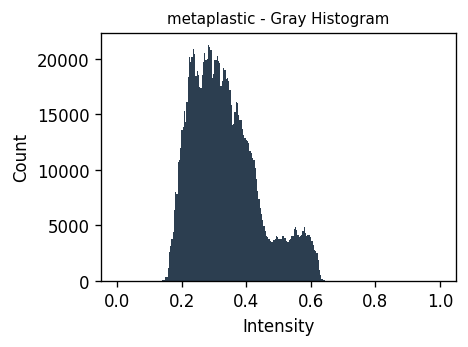

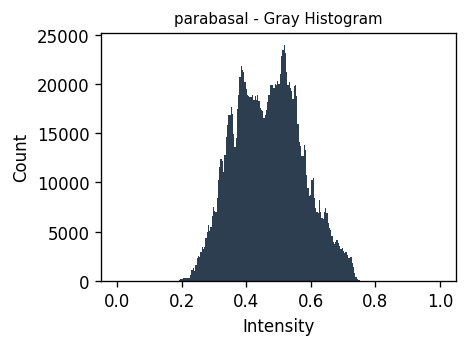

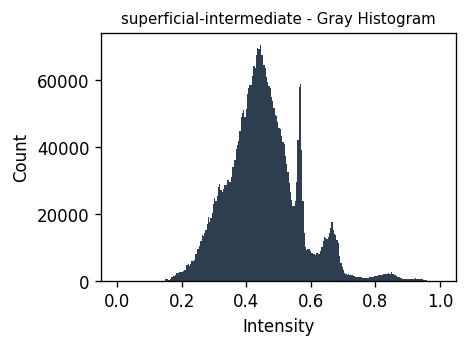

In [13]:
# Aggregate histogram per class from a small random subset
MAX_PER_CLASS = 30

for cls in CLASSES:
    files = list_images_for_class(cls)
    if not files:
        continue
    files = files[:MAX_PER_CLASS]
    pixels = []
    for fpath in files:
        img = load_image(fpath)
        gray = to_gray(img) / 255.0
        pixels.append(gray.flatten())
    pixels = np.concatenate(pixels)

    plt.figure(figsize=(4, 3))
    plt.hist(pixels, bins=256, range=(0, 1), color="#2c3e50")
    plt.title(f"{cls} - Gray Histogram", fontsize=9)
    plt.xlabel("Intensity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

,mean,std,skew,entropy,edge_density,high_freq_energy,local_var,class
0,0.308178,0.102835,0.196358,-386.170019,0.177828,0.048997,0.098789,dyskeratotic
1,0.577998,0.094976,0.644137,-466.336904,0.163329,0.057266,0.069982,dyskeratotic
2,0.421176,0.074937,0.074601,-458.869146,0.156968,0.058383,0.069645,dyskeratotic
3,0.336848,0.063420,-0.910190,-557.547625,0.146159,0.065860,0.060210,dyskeratotic
4,0.272578,0.063783,0.440286,-519.077251,0.201625,0.054569,0.118998,dyskeratotic


mean             std            skew          \
                            mean     std    mean     std    mean     std   
class                                                                      
dyskeratotic              0.4255  0.1021  0.1120  0.0423  0.0364  0.5569   
koilocytotic              0.5716  0.1090  0.1625  0.0322  0.0624  0.5359   
metaplastic               0.4654  0.1234  0.1340  0.0425  0.5993  0.4604   
parabasal                 0.5429  0.1150  0.0804  0.0228 -0.3552  0.4743   
superficial-intermediate  0.6108  0.1295  0.1060  0.0272 -0.2770  0.5599   

                           entropy           edge_density          \
                              mean       std         mean     std   
class                                                               
dyskeratotic             -391.0647  120.1300       0.1707  0.0335   
koilocytotic             -264.1071   83.8419       0.1511  0.0293   
metaplastic              -353.6349   98.6180       0.1402  0.0364   
parabasal                -475.8134  107.3381       0.1926  0.0354   
superficial-intermediate -405.0442   90.4558       0.1094  0.0227   

                         high_freq_energy         local_var          
                                     mean     std      mean     std  
class                                                                
dyskeratotic                       0.0551  0.0150    0.0838  0.0268  
koilocytotic                       0.0506  0.0174    0.0662  0.0222  
metaplastic                        0.0510  0.0149    0.0567  0.0215  
parabasal                          0.0505  0.0132    0.0809  0.0266  
superficial-intermediate           0.0506  0.0141    0.0298  0.0102

<Figure size 600x360 with 0 Axes>

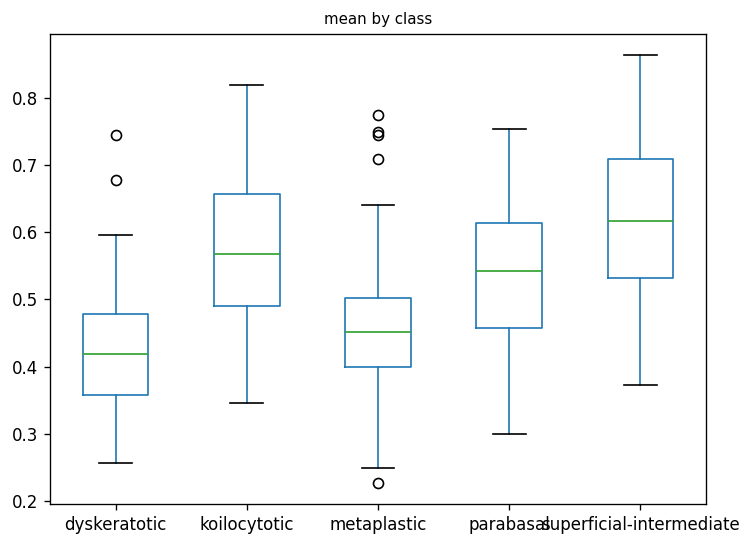

<Figure size 600x360 with 0 Axes>

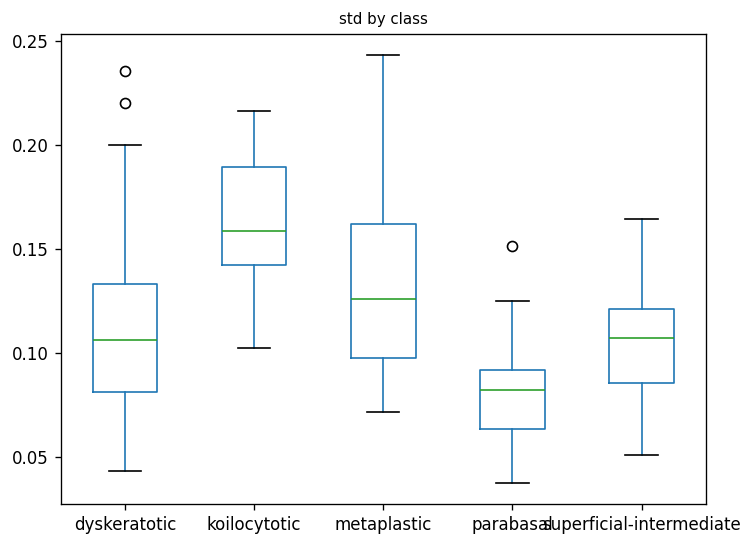

<Figure size 600x360 with 0 Axes>

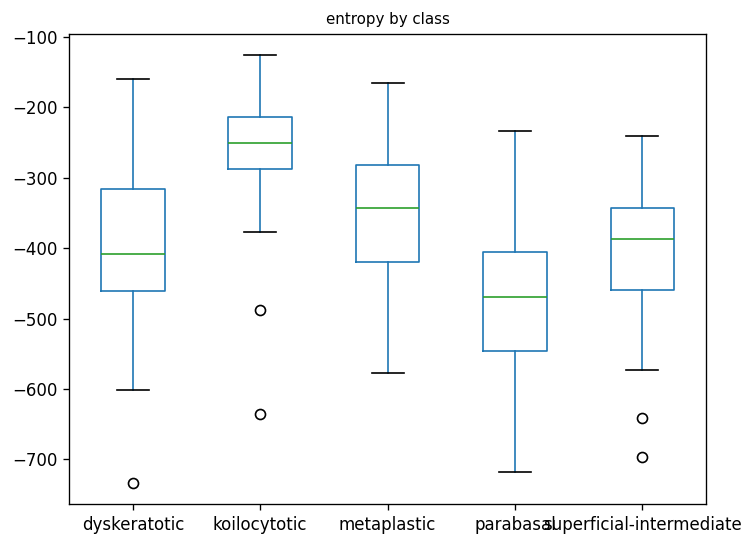

<Figure size 600x360 with 0 Axes>

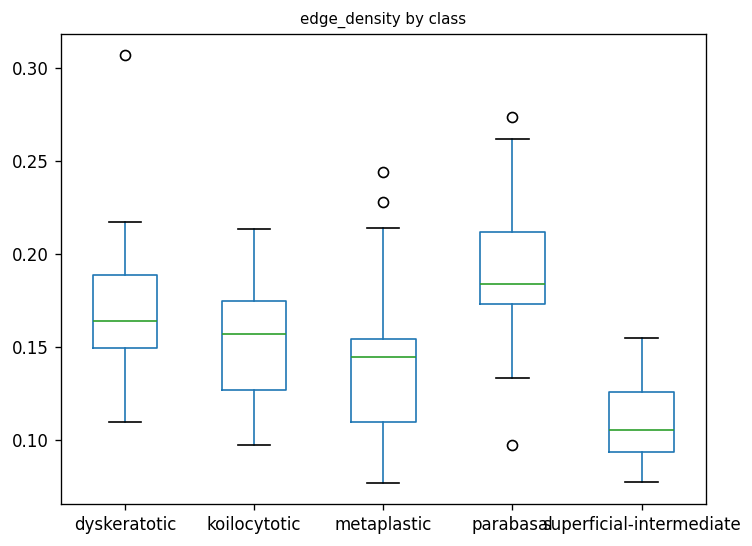

<Figure size 600x360 with 0 Axes>

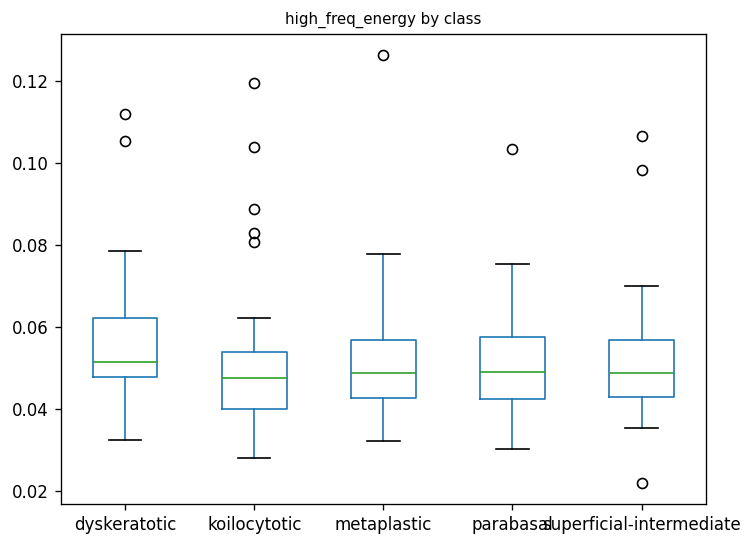

<Figure size 600x360 with 0 Axes>

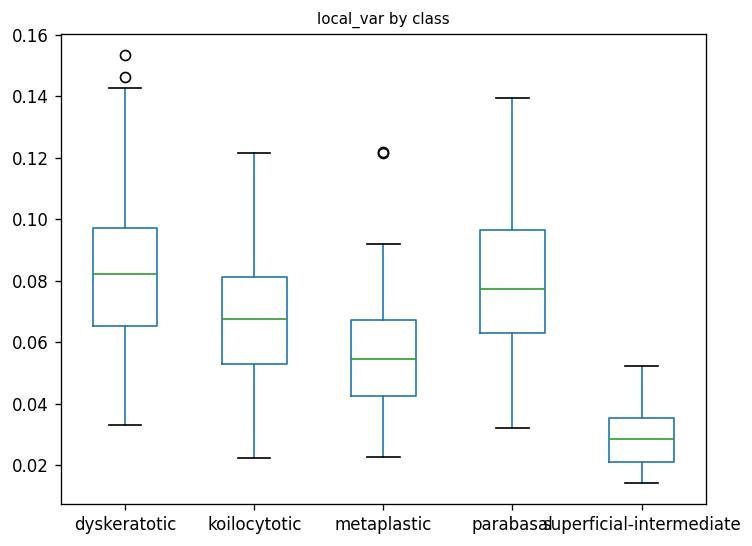

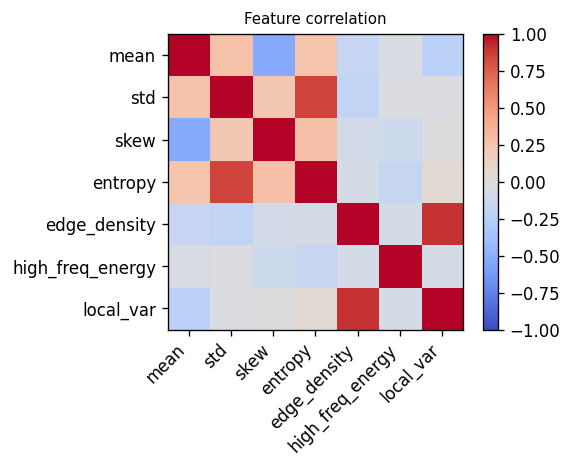

In [14]:
# Feature extraction across a subset of images per class
MAX_FEATURE_SAMPLES = 50

rows = []
for cls in CLASSES:
    files = list_images_for_class(cls)
    if not files:
        continue
    files = random.sample(files, min(len(files), MAX_FEATURE_SAMPLES))
    for fpath in files:
        img = load_image(fpath)
        gray = to_gray(img) / 255.0
        edges = sobel_edges(gray)
        hp = fft_highpass(gray, radius=20)
        varmap = local_variance(gray, k=7)

        feats = extract_features(gray, edges, hp, varmap)
        feats["class"] = cls
        rows.append(feats)

if not rows:
    print("No features extracted. Check file paths and extensions.")
else:
    df = pd.DataFrame(rows)
    display(df.head())

    # Summary statistics per class
    stats = df.groupby("class").agg(["mean", "std"]).round(4)
    display(stats)

    # Boxplots for feature distributions per class
    features_to_plot = ["mean", "std", "entropy", "edge_density", "high_freq_energy", "local_var"]
    for feat in features_to_plot:
        plt.figure(figsize=(5, 3))
        df.boxplot(column=feat, by="class", grid=False)
        plt.title(f"{feat} by class", fontsize=9)
        plt.suptitle("")
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

    # Correlation among features
    plt.figure(figsize=(5, 4))
    corr = df.drop(columns=["class"]).corr()
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Feature correlation", fontsize=9)
    plt.tight_layout()
    plt.show()

## Deeper feature analysis
This section extracts simple numerical descriptors from each class and compares their distributions. It helps identify which transforms highlight class differences that can be used as extra features.

## Notes for feature engineering
You can extract numerical features from these transforms and feed them to your network or a classical model, for example:
- Intensity histogram moments (mean, std, skew)
- Edge density (mean of Sobel magnitude)
- High-frequency energy from FFT magnitude
- Texture descriptors computed over contrast-stretched or equalized images